# INR Classification with Neural Graphs


## Import Dependencies

In [ ]:
%matplotlib inline

import logging
from pathlib import Path

import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader
import torch_geometric.utils
import torchvision
from tqdm import trange
import wandb

from experiments.data import INRDataset
from experiments.utils import count_parameters, set_logger, set_seed
from experiments.lr_scheduler import WarmupLRScheduler
from nn.relational_transformer import RelationalTransformer
from nn.gnn import GNNForClassification
from nn.dws.models import MLPModelForClassification
from nn.inr import INRPerLayer

set_logger()

## INR Dataset


### INR Reconstruction

First let's take a look at some INRs and INR augmentations

In [3]:
dataset_dir = "../experiments/inr_classification/dataset"
splits_path = "mnist_splits.json"
statistics_path = "mnist_statistics.pth"
img_shape = (28, 28)
batch_size = 64

In [4]:
orig_mnist = torchvision.datasets.MNIST(
    Path(dataset_dir) / "mnist",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

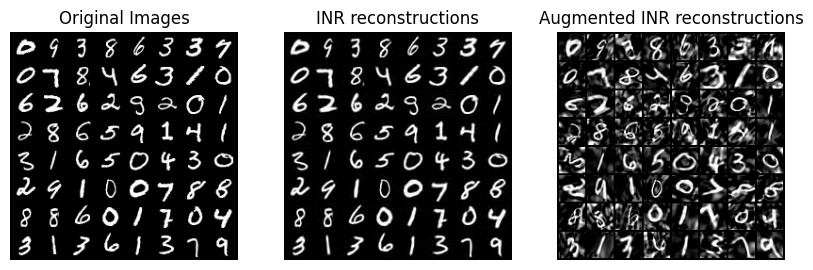

In [5]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision.utils import save_image, make_grid
orig_mnist = torchvision.datasets.MNIST(
    Path(dataset_dir) / "mnist",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)
from experiments.data import BatchSiren, INRDataset

dataset = INRDataset(
    dataset_dir=dataset_dir,
    split="train",
    normalize=False,
    augmentation=False,
    splits_path=splits_path,
    statistics_path=statistics_path,
)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
batch = next(iter(loader))
#print(batch)
dataset_aug = INRDataset(
    dataset_dir=dataset_dir,
    split="train",
    normalize=False,
    augmentation=True,
    splits_path=splits_path,
    statistics_path=statistics_path,
)
loader_aug = torch.utils.data.DataLoader(
    dataset_aug, batch_size=batch_size, shuffle=False
)
batch_aug = next(iter(loader_aug))

inr_model = BatchSiren(2, 1, img_shape=img_shape)
out = inr_model(batch.weights, batch.biases)
out = out.transpose(1, 2).unflatten(2, img_shape)

out_aug = inr_model(batch_aug.weights, batch_aug.biases)
out_aug = out_aug.transpose(1, 2).unflatten(2, img_shape)

indices = [
    int(p.parts[-3].split("_")[-1]) for p in dataset.dataset["path"][:batch_size]
]
orig_images = [orig_mnist[idx][0] for idx in indices]

fig, ax = plt.subplots(1, 3, figsize=(10, 20))

ax[0].imshow(make_grid(orig_images).permute(1, 2, 0).clip(0, 1))
ax[0].set_title("Original Images")
ax[0].set_axis_off()

ax[1].imshow(make_grid(out).permute(1, 2, 0).clip(0, 1))
ax[1].set_title("INR reconstructions")
ax[1].set_axis_off()

ax[2].imshow(make_grid(out_aug).permute(1, 2, 0).clip(0, 1))
ax[2].set_title("Augmented INR reconstructions")
ax[2].set_axis_off()

In [6]:
train_set = INRDataset(
    dataset_dir=dataset_dir,
    split="train",
    normalize=False,
    augmentation=True,
    splits_path=splits_path,
    statistics_path=statistics_path,
)
val_set = INRDataset(
    dataset_dir=dataset_dir,
    split="val",
    normalize=False,
    splits_path=splits_path,
    statistics_path=statistics_path,
)

test_set = INRDataset(
    dataset_dir=dataset_dir,
    split="test",
    normalize=False,
    splits_path=splits_path,
    statistics_path=statistics_path,
)

---

### Create Dataloaders

In [7]:
import logging
batch_size = 64
num_workers = 8

train_loader = torch.utils.data.DataLoader(
    dataset=train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
val_loader = torch.utils.data.DataLoader(
    dataset=val_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

logging.info(
    f"train size {len(train_set)}, "
    f"val size {len(val_set)}, "
    f"test size {len(test_set)}"
)

2025-05-11 21:33:31,120 - root - INFO - train size 2566, val size 500, test size 491


In [9]:
point = train_set.__getitem__(0)
print(list(point.as_dict().keys()))

# weights
print("Weights:", [w.shape for w in point.weights])

# biases
print("Biases:", [b.shape for b in point.biases])

['weights', 'biases', 'label']
Weights: [torch.Size([2, 32, 1]), torch.Size([32, 32, 1]), torch.Size([32, 1, 1])]
Biases: [torch.Size([32, 1]), torch.Size([32, 1]), torch.Size([1, 1])]


---

## Initialize Neural Graphs Transformer

In [10]:
import torch
import logging
# get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"device = {device}")

2025-05-11 21:35:37,738 - root - INFO - device = cpu


In [11]:
# Compute the layer layout
point = train_set[0]
weight_shapes = tuple(w.shape[:2] for w in point.weights)
bias_shapes = tuple(b.shape[:1] for b in point.biases)

layer_layout = [weight_shapes[0][0]] + [b[0] for b in bias_shapes]

logging.info(f"weight shapes: {weight_shapes}, bias shapes: {bias_shapes}")

2025-05-11 21:35:41,787 - root - INFO - weight shapes: (torch.Size([2, 32]), torch.Size([32, 32]), torch.Size([32, 1])), bias shapes: (torch.Size([32]), torch.Size([32]), torch.Size([1]))


In [12]:
stats = {
    "weights_mean": [
        -4.215954686515033e-05,
        -7.55547659991862e-07,
        7.886120874900371e-05,
    ],
    "weights_std": [0.06281130015850067, 0.018268151208758354, 0.11791174858808517],
    "biases_mean": [
        5.419965418695938e-06,
        3.7173406326473923e-06,
        -0.01239530649036169,
    ],
    "biases_std": [0.021334609016776085, 0.011004417203366756, 0.09989194571971893],
}

In [13]:
# inr_model = INRPerLayer(n_layers=3, up_scale=16, out_channels=1)
from omegaconf import OmegaConf
from nn.relational_transformer import RelationalTransformer
inr_model = None
d_node = 64
d_edge = 32

graph_constructor = OmegaConf.create(
    {
        "_target_": "nn.graph_constructor.GraphConstructor",
        "_recursive_": False,
        "_convert_": "all",
        "d_in": 1,
        "d_edge_in": 1,
        "zero_out_bias": False,
        "zero_out_weights": False,
        "sin_emb": True,
        "sin_emb_dim": 128,
        "use_pos_embed": True,
        "input_layers": 1,
        "inp_factor": 1,
        "num_probe_features": 0,
        "inr_model": inr_model,
        "stats": stats,
    }
)

model = RelationalTransformer(
    d_node=d_node,
    d_edge=d_edge,
    d_attn_hid=128,
    d_node_hid=128,
    d_edge_hid=64,
    d_out_hid=128,
    d_out=10,
    n_layers=4,
    n_heads=8,
    layer_layout=layer_layout,
    graph_constructor=graph_constructor,
    dropout=0.0,
    use_cls_token=False,
    pooling_method="cat",
    pooling_layer_idx="last",
).to(device)

In [14]:
from experiments.utils import count_parameters
logging.info(f"number of parameters: {count_parameters(model)}")

2025-05-11 21:36:06,401 - root - INFO - number of parameters: 376586


## Eval Function

In [15]:
@torch.no_grad()
def evaluate(model, loader, device, num_batches=None):
    model.eval()
    loss = 0.0
    correct = 0.0
    total = 0.0
    predicted, gt = [], []
    for i, batch in enumerate(loader):
        if num_batches is not None and i >= num_batches:
            break
        batch = batch.to(device)
        inputs = (batch.weights, batch.biases)
        out = model(inputs)
        loss += F.cross_entropy(out, batch.label, reduction="sum")
        total += len(batch.label)
        pred = out.argmax(1)
        correct += pred.eq(batch.label).sum()
        predicted.extend(pred.cpu().numpy().tolist())
        gt.extend(batch.label.cpu().numpy().tolist())

    model.train()
    avg_loss = loss / total
    avg_acc = correct / total

    return dict(avg_loss=avg_loss, avg_acc=avg_acc, predicted=predicted, gt=gt)

## Model training

In [16]:
from experiments.lr_scheduler import WarmupLRScheduler
from nn.relational_transformer import RelationalTransformer
d_node = 64
d_edge = 32

model = RelationalTransformer(
    d_node=d_node,
    d_edge=d_edge,
    d_attn_hid=128,
    d_node_hid=128,
    d_edge_hid=64,
    d_out_hid=128,
    d_out=10,
    n_layers=4,
    n_heads=8,
    layer_layout=layer_layout,
    graph_constructor=graph_constructor,
    dropout=0.0,
    use_cls_token=False,
    pooling_method="cat",
    pooling_layer_idx="last",
).to(device)
parameters = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    params=parameters, lr=1e-3, amsgrad=True, weight_decay=5e-4, fused=False
)
scheduler = WarmupLRScheduler(warmup_steps=1000, optimizer=optimizer)

In [17]:
epochs = 50  # doing just 50 epochs here
eval_every = 500

global_step = 0
criterion = nn.CrossEntropyLoss()

val_acc = -1
val_loss = float("inf")
best_val_acc = -1
best_val_loss = float("inf")

In [ ]:
epoch_iter = trange(epochs)
for epoch in epoch_iter:
    for i, batch in enumerate(train_loader):
        model.train()
        optimizer.zero_grad()

        batch = batch.to(device)
        inputs = (batch.weights, batch.biases)
        label = batch.label

        out = model(inputs)
        loss = criterion(out, label)
        loss.backward()

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        epoch_iter.set_description(
            f"[{epoch} {i+1}], train loss: {loss.item():.3f}, val loss: {val_loss:.3f}, val acc: {val_acc:.3f}, "
            f"best val loss: {best_val_loss:.3f}, best val acc: {best_val_acc:.3f}"
        )

        global_step += 1

        if (global_step + 1) % eval_every == 0:
            val_loss_dict = evaluate(model, val_loader, device)
            val_loss = val_loss_dict["avg_loss"]
            val_acc = val_loss_dict["avg_acc"]

            best_val_criteria = val_acc >= best_val_acc
            if best_val_criteria:
                best_val_acc = val_acc
                best_val_loss = val_loss

[46 41], train loss: 1.320, val loss: 2.286, val acc: 0.342, best val loss: 2.286, best val acc: 0.342:  94%|█████████▍| 47/50 [3:58:07<15:16, 305.34s/it]  

In [3]:
test_loss_dict = evaluate(model, test_loader, device)
test_loss = test_loss_dict["avg_loss"]
test_acc = test_loss_dict["avg_acc"]

logging.info(
    f"[ train loss: {loss.item():.3f}, test loss: {test_loss:.3f}, test acc: {test_acc:.3f}"
)

2025-05-14 00:56:53,805 - root - INFO - [ train loss: 0.046, test loss: 0.266, test acc: 0.913


---

## Initialize Neural Graphs Graph Neural Network

In [18]:
# inr_model = INRPerLayer(n_layers=3, up_scale=16, out_channels=1)
inr_model = None
from omegaconf import OmegaConf
graph_constructor = OmegaConf.create(
    {
        "_target_": "nn.graph_constructor.GraphConstructor",
        "_recursive_": False,
        "_convert_": "all",
        "d_in": 1,
        "d_edge_in": 1,
        "zero_out_bias": False,
        "zero_out_weights": False,
        "sin_emb": True,
        "sin_emb_dim": 128,
        "use_pos_embed": True,
        "input_layers": 1,
        "inp_factor": 1,
        "num_probe_features": 0,
        "inr_model": inr_model,
        "stats": stats,
    }
)

gnn_backbone = OmegaConf.create(
    {
        "_target_": "nn.gnn.PNA",
        "_convert_": "all",
        "in_channels": 32,
        "hidden_channels": 32,
        "out_channels": 32,
        "num_layers": 4,
        "aggregators": ["mean", "min", "max", "std"],
        "scalers": ["identity", "amplification"],
        "edge_dim": 32,
        "dropout": 0.1,
        "norm": "layernorm",
        "act": "silu",
        "deg": None,
        "update_edge_attr": True,  # Check with False as well
        "modulate_edges": True,
        "gating_edges": False,
        "final_edge_update": False,
    }
)

gnn_model = GNNForClassification(
    d_hid=32,
    d_out=10,
    graph_constructor=graph_constructor,
    gnn_backbone=gnn_backbone,
    layer_layout=layer_layout,
    rev_edge_features=False,
    pooling_method="cat",
    pooling_layer_idx="last",
).to(device)

In [19]:
logging.info(f"number of parameters: {count_parameters(model)}")

2025-05-11 21:37:11,794 - root - INFO - number of parameters: 376586


## Model training

In [20]:
gnn_parameters = [p for p in gnn_model.parameters() if p.requires_grad]
gnn_optimizer = torch.optim.AdamW(
    params=gnn_parameters, lr=1e-3, amsgrad=True, weight_decay=5e-4, fused=False
)
scheduler = WarmupLRScheduler(warmup_steps=1000, optimizer=gnn_optimizer)

In [21]:
epochs = 50  # doing just 50 epochs here
eval_every = 500

global_step = 0
criterion = nn.CrossEntropyLoss()

val_acc = -1
val_loss = float("inf")
best_val_acc = -1
best_val_loss = float("inf")

In [22]:
epoch_iter = trange(epochs)
for epoch in epoch_iter:
    for i, batch in enumerate(train_loader):
        gnn_model.train()
        gnn_optimizer.zero_grad()

        batch = batch.to(device)
        inputs = (batch.weights, batch.biases)
        label = batch.label

        out = gnn_model(inputs)
        loss = criterion(out, label)
        loss.backward()

        gnn_optimizer.step()

        if scheduler is not None:
            scheduler.step()

        epoch_iter.set_description(
            f"[{epoch} {i+1}], train loss: {loss.item():.3f}, val loss: {val_loss:.3f}, val acc: {val_acc:.3f}, "
            f"best val loss: {best_val_loss:.3f}, best val acc: {best_val_acc:.3f}"
        )

        global_step += 1

        if (global_step + 1) % eval_every == 0:
            val_loss_dict = evaluate(gnn_model, val_loader, device)
            val_loss = val_loss_dict["avg_loss"]
            val_acc = val_loss_dict["avg_acc"]

            best_val_criteria = val_acc >= best_val_acc
            if best_val_criteria:
                best_val_acc = val_acc
                best_val_loss = val_loss

  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\Com Plus\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
[49 41], train loss: 1.620, val loss: 1.886, val acc: 0.304, best val loss: 1.886, best val acc: 0.304: 100%|██████████| 50/50 [1:16:10<00:00, 91.41s/it] 


In [23]:
test_loss_dict = evaluate(model, test_loader, device)
test_loss = test_loss_dict["avg_loss"]
test_acc = test_loss_dict["avg_acc"]

logging.info(
    f"[{epoch} {i+1}], train loss: {loss.item():.3f}, test loss: {test_loss:.3f}, test acc: {test_acc:.3f}"
)

2025-05-11 23:04:31,867 - root - INFO - [49 41], train loss: 1.620, test loss: 2.326, test acc: 0.084
